In [1]:
from deepinv.physics import BlurFFT, GaussianNoise, MRI, Blur
from deepinv.physics.blur import gaussian_blur 
from deepinv.loss.metric import PSNR, LPIPS
from deepinv.utils import plot
import torch
import matplotlib.pyplot as plt
import numpy as np
import os
from utils import json_to_dict, normalize
import tqdm

device = torch.device('cuda')

In [2]:
lpips = LPIPS(device=device)

def extract_results_comp(folder, exp_type="mri", cut_padding=True, 
                         indstart=None, indend=None):
    """Extract metrics from the samples generated in the given folder. 
    -exp_type: 'ffhq' (natural images) or 'mri'. If 'ffhq', set cut_padding to True to remove the padding
    used in the BlurFFT method before computing the metrics."""
    
    if indstart is None:
        paths = []
        for path in os.listdir(folder):
            if "trace_" in path:
                paths.append(path)
        indstart, indend = 0, len(paths)-1
    else:
        if indend is None:
            print("indend should be specified")
            return 
    nref = indend - indstart + 1
    
    metrics_x = dict()
    
    metrics_x["perceptual"] =  np.zeros(nref)
    metrics_x["euclidian"] =  np.zeros(nref)
    metrics_x["euclidianx"] =  np.zeros(nref)
    metrics_x["euclidianGT"] =  np.zeros(nref)
    metrics_x["perceptualGT"] =  np.zeros(nref)
    
    config_dict = json_to_dict(os.path.join(folder, "config.json"))
    
    if exp_type == "ffhq" and cut_padding:
        blur_op = Blur(img_size=(3, 256, 256), 
                                   filter=gaussian_blur(sigma=(config_dict["sigma_blur"], 
                                                               config_dict["sigma_blur"])), 
                       device=device, padding='valid').to(device) 
        x = torch.randn(1, 3, 256, 256)
        res = blur_op(x.to(device)).shape[-1]
        cut = (256 - res)//2

    i = 0
    for ind in tqdm.tqdm(range(indstart, indend+1)):
        with torch.no_grad():
            trace_dict = np.load(os.path.join(folder, "trace_{}.npz".format(ind)))
            x_hat = torch.tensor(trace_dict["samples_xp"], device=device).clamp(0, 1)
            x = torch.tensor(trace_dict["x"], device=device)
            x_samples = torch.tensor(trace_dict["samples_x"], device=device).clamp(0, 1)
            nb_noise, nb_steps = x_samples.shape[0], x_samples.shape[1]
            x_samples = x_samples.reshape((-1,) + x.shape[-3:])
            y = trace_dict["y"]
            yp_samples = torch.tensor(trace_dict["samples_yp"], device=device)

            if exp_type == 'mri':  # in that case, initialize from trace_dict
                physics_loc = MRI(mask=trace_dict["mask"], device=device)
                x_samples_cp = torch.zeros((nb_noise*nb_steps, 2) + x_samples.shape[-2:]).to(device)
                x_samples_cp[:, 0] = x_samples.view((-1,) + x_samples.shape[-2:])
                x_samples_proj = physics_loc(x_samples_cp)
            else:
                sb = config_dict["sigma_blur"]
                physics_loc = BlurFFT(img_size=(3, 256, 256), filter=gaussian_blur(sigma=(sb, sb)), device=device)
                x_samples_proj = physics_loc(x_samples.view((-1,) + x_samples.shape[-3:]))
                if cut_padding:
                    x = x[:, :, cut:256-cut, cut:256-cut]
                    x_samples_proj = x_samples_proj[:, :, cut:256-cut, cut:256-cut]
                    x_samples = x_samples[:, :, cut:256-cut, cut:256-cut]
                    x_hat = x_hat[:, :,  cut:256-cut, cut:256-cut]
                    y = y[:, :, cut:256-cut, cut:256-cut]
                    yp_samples = yp_samples[:, :, cut:256-cut, cut:256-cut]
            # reshape so first dim correspond to noise it, (nb_noise, nb_steps, c, h, w)
            x_samples = x_samples.reshape((nb_noise, nb_steps) + x.shape[-3:])
            yp_samples = yp_samples.reshape((nb_noise, -1))
            x_samples_proj = x_samples_proj.reshape((nb_noise, nb_steps) + y.shape[-3:])
            for t in range(nb_noise):
                metrics_x["perceptual"][i] +=  torch.sum(lpips(x_hat[t].unsqueeze(0), x_samples[t]))
                metrics_x["euclidian"][i] +=  torch.sum(torch.norm(yp_samples[t].view([1, -1]) - x_samples_proj[t].reshape([nb_steps, -1]), dim=-1)**2)      
                metrics_x["euclidianx"][i] +=  torch.sum(torch.norm(x_hat[t].reshape([1, -1]) - x_samples[t].reshape([nb_steps, -1]), dim=-1)**2)      
                metrics_x["perceptualGT"][i] +=  torch.sum(lpips(x, x_samples[t]))
                metrics_x["euclidianGT"][i] +=  torch.sum(torch.norm(x.reshape([1, -1]) - x_samples[t].reshape([nb_steps, -1]), dim=-1))      

            metrics_x["perceptual"][i] = metrics_x["perceptual"][i]/nb_steps/nb_noise  
            metrics_x["perceptualGT"][i] = metrics_x["perceptualGT"][i]/nb_steps/nb_noise    
            metrics_x["euclidianGT"][i] = metrics_x["euclidianGT"][i]/nb_steps/nb_noise    

            metrics_x["euclidian"][i] = metrics_x["euclidian"][i]/nb_steps/nb_noise    
            metrics_x["euclidianx"][i] = metrics_x["euclidianx"][i]/nb_steps/nb_noise

            i += 1

    return metrics_x


# distributions for ffhq-trained model
labels = ["afhq", "celeb", "bedrooms", "met", "natural"]
colors = ["crimson", "dodgerblue", "gray", "goldenrod", "purple"]

Loading pretrained model LPIPS from /linkhome/rech/gendho01/uaq36gg/.cache/torch/hub/pyiqa/LPIPS_v0.1_alex-df73285e.pth


In [3]:
# extract results from the FFHQ subset, assuming samples have been computed
res_ref = extract_results_comp("results/diffusion/natural/FFHQ_FFHQ_05", exp_type='ffhq')

np.random.seed(0)
# extract 15 of the 75 images to go to the test dataset
random_inds_test = np.random.choice(75, size=15, replace=False) 
complement_inds = [i for i in range(75) if i not in random_inds_test]

# compute the quantile used for OOD detection 
quant = np.quantile(res_ref["perceptual"][complement_inds], 0.95, method='median_unbiased')

100%|██████████| 75/75 [01:38<00:00,  1.31s/it]


In [4]:
# assume the samples have been computed for the test dataset
res = extract_results_comp("results/diffusion/natural/FFHQ_test_05", exp_type='ffhq')

cats = np.array([0]*15 + [1]*15 + [2]*15 + [3]*15 + [4]*15)
labels = ["AFHQ", "Celeb", "Bedrooms", "Met", "CBSD68"]

# compute reject rates
print("ffhq rejection rate: ", np.mean(res_ref["perceptual"][random_inds_test] > quant))
celeb_ind = (cats == 1)
print("celeb rejection rate: ", np.mean(res["perceptual"][celeb_ind] > quant))

met_ind = (cats == 3)
print("met rejection rate: ", np.mean(res["perceptual"][met_ind] > quant))

strong_ood_ind = (cats == 0) | (cats == 2) | (cats == 4)
print("Strong OOD rejection rate: ", np.mean(res["perceptual"][strong_ood_ind] > quant))

100%|██████████| 75/75 [01:25<00:00,  1.14s/it]

ffhq rejection rate:  0.0
celeb rejection rate:  0.06666666666666667
met rejection rate:  0.8666666666666667
Strong OOD rejection rate:  1.0


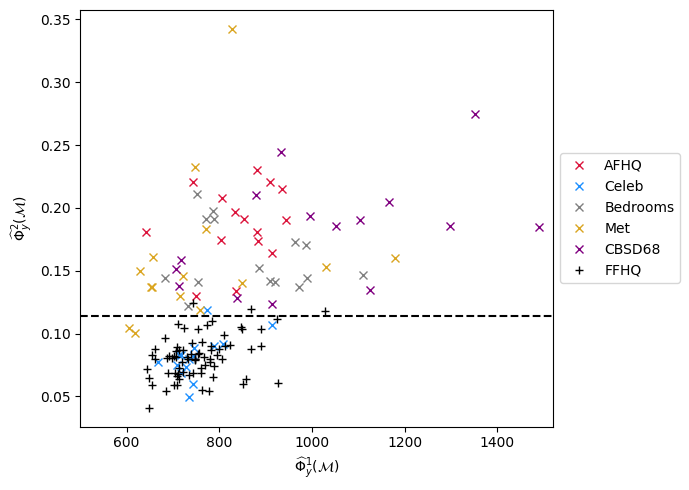

In [5]:
fig, ax= plt.subplots(figsize=(7, 5))
labels = ["AFHQ", "Celeb", "Bedrooms", "Met", "CBSD68"]
colors = ["crimson", "dodgerblue", "gray", "goldenrod", "purple"]

for i in range(5):
    ind = cats == i
    ax.plot(res["euclidian"][ind], res["perceptual"][ind], 'x', color=colors[i], label=labels[i])
    
ax.plot( res_ref["euclidian"], res_ref["perceptual"], '+', color='k', label='FFHQ')

ax.set_xlim(500, 1520)
ax.set_ylabel(r'$\widehat{\Phi}^{2}_{y}(\mathcal{M})$')
ax.set_xlabel(r'$\widehat{\Phi}^{1}_{y}(\mathcal{M})$')

ax.hlines(quant, xmin=ax.get_xlim()[0], xmax=ax.get_xlim()[1], colors='k', linestyles='--')
ax.legend( loc='center left', bbox_to_anchor=(1, 0.5), ncol=1)
plt.tight_layout()